In [193]:
#   Binary Classification using linear and logestic regression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, LogisticRegression

In [194]:
df=pd.read_csv('myinsurance.csv')
df

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,Male,25000,0,Single,0,0,1,No
1,2,25,Female,30000,0,Single,0,0,1,No
2,3,28,Male,35000,1,Single,0,0,1,No
3,4,30,Female,40000,1,Single,0,1,2,Yes
4,5,32,Male,45000,1,Single,0,1,2,Yes
...,...,...,...,...,...,...,...,...,...,...
95,96,46,Female,70000,1,Married,1,2,4,Yes
96,97,51,Male,83000,1,Married,1,3,4,Yes
97,98,56,Female,94000,1,Married,1,3,4,Yes
98,99,24,Male,31000,0,Single,0,0,1,No


In [195]:
df.head()

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,Male,25000,0,Single,0,0,1,No
1,2,25,Female,30000,0,Single,0,0,1,No
2,3,28,Male,35000,1,Single,0,0,1,No
3,4,30,Female,40000,1,Single,0,1,2,Yes
4,5,32,Male,45000,1,Single,0,1,2,Yes


In [196]:
df.tail()

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
95,96,46,Female,70000,1,Married,1,2,4,Yes
96,97,51,Male,83000,1,Married,1,3,4,Yes
97,98,56,Female,94000,1,Married,1,3,4,Yes
98,99,24,Male,31000,0,Single,0,0,1,No
99,100,30,Female,40000,1,Single,0,1,2,Yes


In [197]:
df.shape

(100, 10)

In [198]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Employment_Status',
       'Marital_Status', 'Married', 'Previous_Insurance', 'Family_Size',
       'Buy_Insurance'],
      dtype='str')

In [199]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Customer_ID         100 non-null    int64
 1   Age                 100 non-null    int64
 2   Gender              100 non-null    str  
 3   Annual_Income       100 non-null    int64
 4   Employment_Status   100 non-null    int64
 5   Marital_Status      100 non-null    str  
 6   Married             100 non-null    int64
 7   Previous_Insurance  100 non-null    int64
 8   Family_Size         100 non-null    int64
 9   Buy_Insurance       100 non-null    str  
dtypes: int64(7), str(3)
memory usage: 7.9 KB


In [200]:
df.isnull().sum()

Customer_ID           0
Age                   0
Gender                0
Annual_Income         0
Employment_Status     0
Marital_Status        0
Married               0
Previous_Insurance    0
Family_Size           0
Buy_Insurance         0
dtype: int64

In [201]:
df.corr(numeric_only=True)

,Customer_ID,Age,Annual_Income,Employment_Status,Married,Previous_Insurance,Family_Size
Customer_ID,1.000000,0.158170,0.180054,0.049803,0.133401,0.156457,0.150810
Age,0.158170,1.000000,0.998332,0.650960,0.834590,0.960055,0.956927
Annual_Income,0.180054,0.998332,1.000000,0.650526,0.839337,0.961360,0.957596
Employment_Status,0.049803,0.650960,0.650526,1.000000,0.557578,0.610820,0.689424
Married,0.133401,0.834590,0.839337,0.557578,1.000000,0.820608,0.848247
Previous_Insurance,0.156457,0.960055,0.961360,0.610820,0.820608,1.000000,0.933681
Family_Size,0.150810,0.956927,0.957596,0.689424,0.848247,0.933681,1.000000


In [202]:
text_data=list[df.select_dtypes(str).columns]
text_data

list[Index(['Gender', 'Marital_Status', 'Buy_Insurance'], dtype='str')]

In [203]:
for i in text_data:
    print(f"Analysis Data{i}")
    display(df[i].value_counts())

Analysis Data*list[Index(['Gender', 'Marital_Status', 'Buy_Insurance'], dtype='str')]


Customer_ID  Age  Gender  Annual_Income  Employment_Status  Marital_Status  Married  Previous_Insurance  Family_Size  Buy_Insurance
1            22   Male    25000          0                  Single          0        0                   1            No               1
2            25   Female  30000          0                  Single          0        0                   1            No               1
3            28   Male    35000          1                  Single          0        0                   1            No               1
4            30   Female  40000          1                  Single          0        1                   2            Yes              1
5            32   Male    45000          1                  Single          0        1                   2            Yes              1
                                                                                                                                      ..
96           46   Female  70000          1    

In [204]:
df["Gender"]=df["Gender"].replace({'Male':0,'Female':1})
df

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,0,25000,0,Single,0,0,1,No
1,2,25,1,30000,0,Single,0,0,1,No
2,3,28,0,35000,1,Single,0,0,1,No
3,4,30,1,40000,1,Single,0,1,2,Yes
4,5,32,0,45000,1,Single,0,1,2,Yes
...,...,...,...,...,...,...,...,...,...,...
95,96,46,1,70000,1,Married,1,2,4,Yes
96,97,51,0,83000,1,Married,1,3,4,Yes
97,98,56,1,94000,1,Married,1,3,4,Yes
98,99,24,0,31000,0,Single,0,0,1,No


In [205]:
df["Buy_Insurance"]=df["Buy_Insurance"].replace({'No':0,'Yes':1})
df

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,0,25000,0,Single,0,0,1,0
1,2,25,1,30000,0,Single,0,0,1,0
2,3,28,0,35000,1,Single,0,0,1,0
3,4,30,1,40000,1,Single,0,1,2,1
4,5,32,0,45000,1,Single,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...
95,96,46,1,70000,1,Married,1,2,4,1
96,97,51,0,83000,1,Married,1,3,4,1
97,98,56,1,94000,1,Married,1,3,4,1
98,99,24,0,31000,0,Single,0,0,1,0


In [206]:
df["Marital_Status"]=df["Marital_Status"].replace({'Single':0,'Married':1})
df

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,0,25000,0,0,0,0,1,0
1,2,25,1,30000,0,0,0,0,1,0
2,3,28,0,35000,1,0,0,0,1,0
3,4,30,1,40000,1,0,0,1,2,1
4,5,32,0,45000,1,0,0,1,2,1
...,...,...,...,...,...,...,...,...,...,...
95,96,46,1,70000,1,1,1,2,4,1
96,97,51,0,83000,1,1,1,3,4,1
97,98,56,1,94000,1,1,1,3,4,1
98,99,24,0,31000,0,0,0,0,1,0


In [207]:
df.corr().round(2)

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
Customer_ID,1.00,0.16,0.02,0.18,0.05,0.13,0.13,0.16,0.15,0.09
Age,0.16,1.00,0.02,1.00,0.65,0.83,0.83,0.96,0.96,0.73
Gender,0.02,0.02,1.00,0.02,-0.02,-0.02,-0.02,0.02,0.01,0.02
Annual_Income,0.18,1.00,0.02,1.00,0.65,0.84,0.84,0.96,0.96,0.73
Employment_Status,0.05,0.65,-0.02,0.65,1.00,0.56,0.56,0.61,0.69,0.82
Marital_Status,0.13,0.83,-0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Married,0.13,0.83,-0.02,0.84,0.56,1.00,1.00,0.82,0.85,0.68
Previous_Insurance,0.16,0.96,0.02,0.96,0.61,0.82,0.82,1.00,0.93,0.75
Family_Size,0.15,0.96,0.01,0.96,0.69,0.85,0.85,0.93,1.00,0.77
Buy_Insurance,0.09,0.73,0.02,0.73,0.82,0.68,0.68,0.75,0.77,1.00


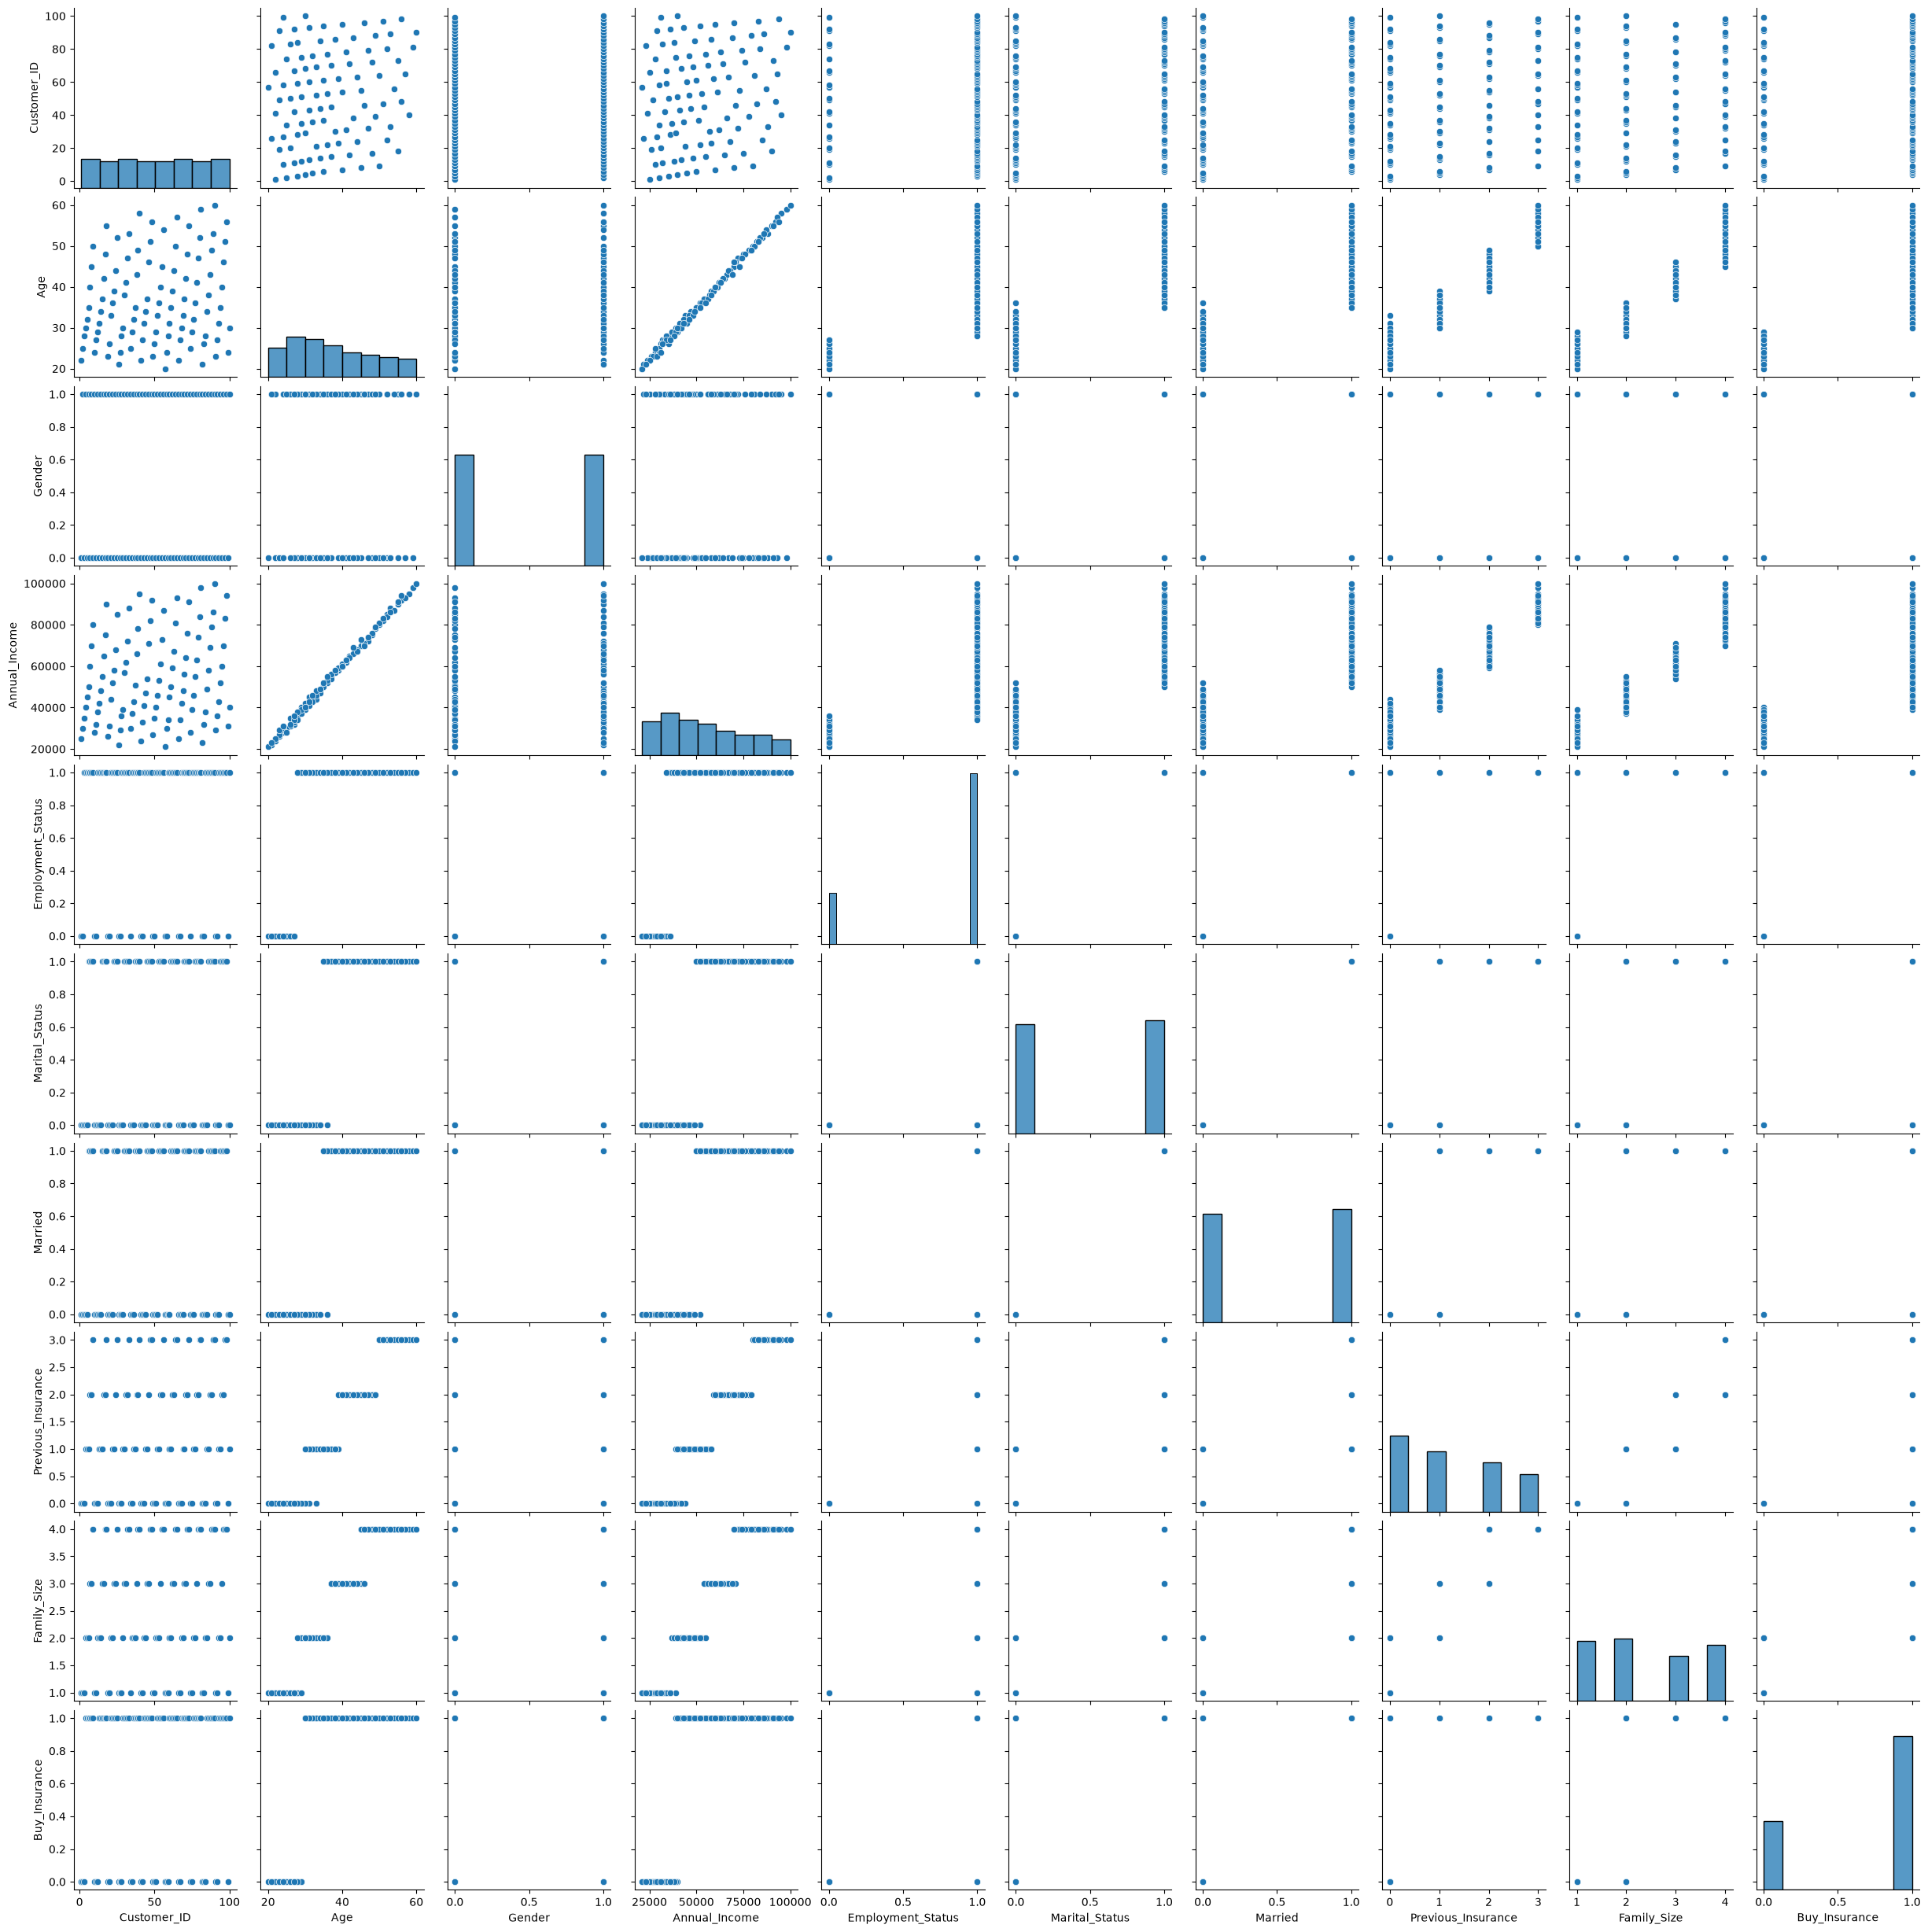

In [208]:
sns.pairplot(data=df)

<Axes: >

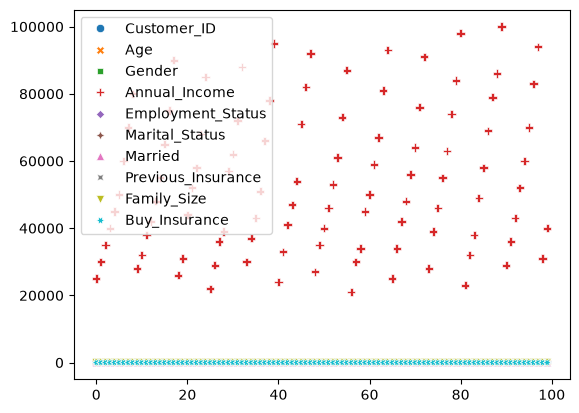

In [209]:
sns.scatterplot(data=df)

In [210]:
X=df.drop(columns=["Buy_Insurance","Customer_ID"]).astype(int)
y=df["Buy_Insurance"]

In [211]:
X.shape

(100, 8)

In [212]:
from sklearn.model_selection import train_test_split


In [213]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)

In [214]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(80, 8)
(20, 8)
(80,)
(20,)


In [215]:
model=LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [216]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.05, 0.07, 0. ,..., 0.05, 0.28, 0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Age','Gender','Annual_Income',...,'Married','Previous_Insurance', 'Family_Size']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.7499
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [217]:
y_pred=model.predict(X_test)
y_pred

array([ 0.47985799,  0.52928062,  1.07344988,  0.80411021,  0.05110574,
       -0.03636979,  0.94684651,  1.0923136 ,  0.68091132,  1.16009442,
        0.03217814,  0.90021855,  0.91768801,  0.03446727,  0.92682635,
        0.81697849,  0.88040221,  0.00301963,  1.03425816,  0.72899743])

In [218]:
y_test

20    1
2     0
15    1
22    1
57    0
91    0
69    1
55    1
11    0
79    1
9     0
38    1
85    1
0     0
89    1
13    1
5     1
1     0
95    1
83    0
Name: Buy_Insurance, dtype: object

In [219]:
sigmoid(y_pred)

array([0.61771427, 0.62931523, 0.7452523 , 0.69085289, 0.51277365,
       0.49090856, 0.72048042, 0.748817  , 0.66394196, 0.76134973,
       0.50804383, 0.71099429, 0.71457066, 0.50861596, 0.71643085,
       0.69359446, 0.70690544, 0.50075491, 0.73774046, 0.67458512])

In [220]:
final_y_pred=[round(i)for i in sigmoid(y_pred)]
final_y_pred

[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [221]:
score=model.score(X_test,y_test)
score

0.6450551271911066

In [222]:
model_logistic=LogisticRegression()
model_logistic

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [229]:
y_train = y_train.astype(int)
y_test = y_test.astype(int)
model_logistic.fit(X_train, y_train)

/opt/homebrew/Cellar/jupyterlab/4.6.3/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [230]:
y_prd = model_logistic.predict(X_test)
y_prd

array([1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0])

In [232]:
sigmoid(y_prd)

array([0.73105845, 0.5       , 0.73105845, 0.73105845, 0.5       ,
       0.5       , 0.73105845, 0.73105845, 0.5       , 0.73105845,
       0.5       , 0.73105845, 0.73105845, 0.5       , 0.73105845,
       0.73105845, 0.73105845, 0.5       , 0.73105845, 0.5       ])

In [238]:
score = model_logistic.score(X_test,y_test)
score

1.0

In [234]:
df.head(5)

,Customer_ID,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,1,22,0,25000,0,0,0,0,1,0
1,2,25,1,30000,0,0,0,0,1,0
2,3,28,0,35000,1,0,0,0,1,0
3,4,30,1,40000,1,0,0,1,2,1
4,5,32,0,45000,1,0,0,1,2,1


In [236]:
age = int(input("Enter Age:"))
gend = int(input("Enter Gender(1 for Male & 0 for Female):"))
inc = int(input("Enter Income:"))
emp_status = int(input("Having a job currently(0 for No & 1 for Yes):"))
mstatus = int(input("Enter(0 for Single & 1 for Married):"))
married = int(input("Enter O & 1:"))
prev_ins = int(input("Enter total insurance till date"))
family = int(input("Enter no of family members :"))


data = [[
    age,gend,inc,emp_status,mstatus,married,prev_ins,family
]]
prediction = model_logistic.predict(data)[0]
final = "No, no immidiate no to take insurance" if prediction == 0 else "Yes, you should take insurance"


print(final)
print(f"Model giving answer with {score*100}% accuracy")

Enter Age: 28
Enter Gender(1 for Male & 0 for Female): 1
Enter Income: 120000
Having a job currently(0 for No & 1 for Yes): 1
Enter(0 for Single & 1 for Married): 0
Enter O & 1: 0
Enter total insurance till date 1
Enter no of family members : 4


Yes, you should take insurance
Model giving answer with 100.0% accuracy


/opt/homebrew/Cellar/jupyterlab/4.6.3/libexec/lib/python3.14/site-packages/sklearn/utils/validation.py:2830: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


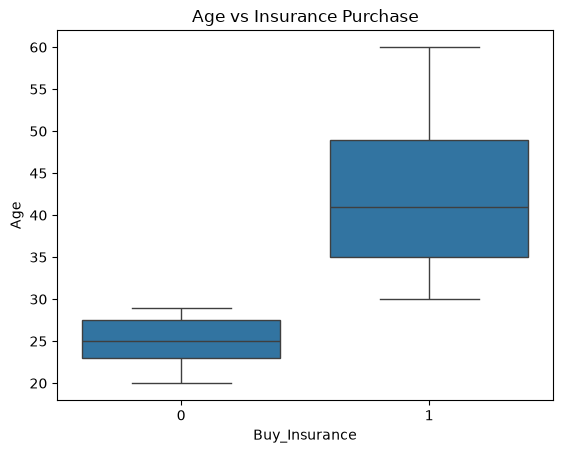

In [243]:
sns.boxplot(
    data=df,
    x="Buy_Insurance",
    y="Age"
)

plt.title("Age vs Insurance Purchase")
plt.show()

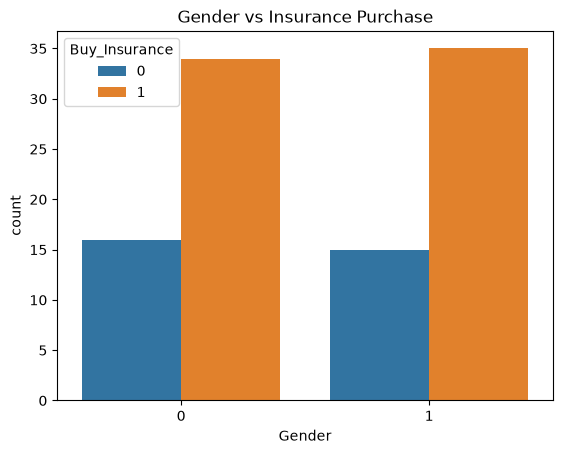

In [244]:
sns.countplot(
    data=df,
    x="Gender",
    hue="Buy_Insurance"
)

plt.title("Gender vs Insurance Purchase")
plt.show()

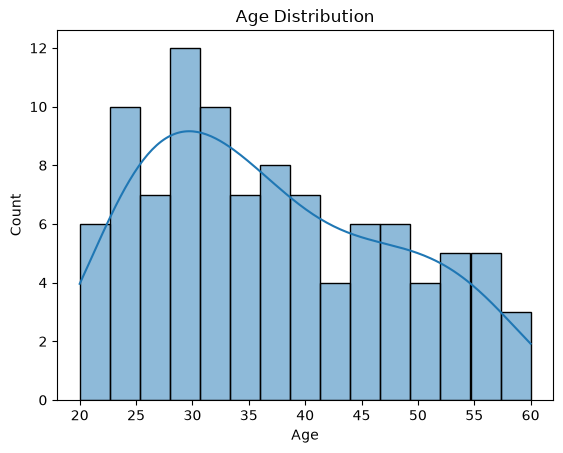

In [247]:
sns.histplot(
    data=df,
    x="Age",
    bins=15,
    kde=True
)

plt.title("Age Distribution")
plt.show()